In [1]:
from google.cloud import bigquery

# BigQuery vers le projet
client = bigquery.Client(project="wagon-bootcamp-501621")

#le nombre de lignes et la liste des colonnes ( afficher)
table = client.get_table("wagon-bootcamp-501621.staging.catnat_staging")
print("Nombre de lignes :", table.num_rows)
for col in table.schema:
    print(col.name, "-", col.field_type)

Nombre de lignes : 247140
id_gaspar - STRING
code_commune - STRING
libelle_commune - STRING
num_risque_jo - STRING
lib_risque_jo - STRING
date_debut - DATE
date_fin - DATE
date_signature_arrete - DATE
date_publication_jo - DATE
date_modification - DATE


In [2]:
# Afficher 5 lignes d'exemple
df = client.query("""
    SELECT * FROM `wagon-bootcamp-501621.staging.catnat_staging` LIMIT 5
""").to_dataframe()
df

/Users/asmaammouri/code/Asma-Iam/hydraxai-france/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id_gaspar,code_commune,libelle_commune,num_risque_jo,lib_risque_jo,date_debut,date_fin,date_signature_arrete,date_publication_jo,date_modification
0,NOR19821214,43234,saugues,ICB,inondations et/ou coulees de boue,1982-08-15,1982-08-15,1982-12-14,1982-12-18,2022-05-20
1,NOR19821214,43224,sainte-sigolene,ICB,inondations et/ou coulees de boue,1982-08-15,1982-08-15,1982-12-14,1982-12-18,2022-05-20
2,NOR19820921,69009,anse,ICB,inondations et/ou coulees de boue,1982-08-16,1982-08-16,1982-09-21,1982-09-30,2022-05-20
3,NOR19820921,69163,quincieux,ICB,inondations et/ou coulees de boue,1982-08-16,1982-08-16,1982-09-21,1982-09-30,2022-05-20
4,NOR19820921,69122,lucenay,ICB,inondations et/ou coulees de boue,1982-08-16,1982-08-16,1982-09-21,1982-09-30,2022-05-20


In [3]:
# Compter les arrêtés et les communes pour chaque type de risque
risques = client.query("""
    SELECT
        lib_risque_jo,
        COUNT(*) AS nb_arretes,
        COUNT(DISTINCT code_commune) AS nb_communes
    FROM `wagon-bootcamp-501621.staging.catnat_staging`
    GROUP BY lib_risque_jo
    ORDER BY nb_arretes DESC
""").to_dataframe()
risques

/Users/asmaammouri/code/Asma-Iam/hydraxai-france/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,lib_risque_jo,nb_arretes,nb_communes
0,inondations et/ou coulees de boue,139419,34578
1,secheresse,43417,14222
2,mouvement de terrain,31711,27437
3,tempete,16025,14915
4,chocs mecaniques lies a l'action des vagues,6720,4309
5,glissement de terrain,3182,2699
6,poids de la neige,2758,2758
7,inondations remontee nappe,1368,1152
8,grele,1333,1263
9,secousse sismique,749,682


In [4]:
# Compter les arrêtés inondation de chaque commune
cible = client.query("""
    SELECT
        code_commune,
        COUNT(*) AS nb_arretes_inond
    FROM `wagon-bootcamp-501621.staging.catnat_staging`
    WHERE lib_risque_jo IN ('inondations et/ou coulees de boue',
                            'inondations remontee nappe')
    GROUP BY code_commune
""").to_dataframe()

print("Nombre de communes :", len(cible))
cible["nb_arretes_inond"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

/Users/asmaammouri/code/Asma-Iam/hydraxai-france/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Nombre de communes : 34578


count     34578.0
mean     4.071577
std      2.744101
min           1.0
25%           2.0
50%           3.0
75%           5.0
90%           8.0
99%          13.0
max          37.0
Name: nb_arretes_inond, dtype: Float64

## Cible
- Source : arrêtés CatNat (GASPAR), libellés « inondations et/ou coulées de boue » et « inondations remontée nappe »
- Répartition : médiane = 3 arrêtés, 75e percentile = 5, max = 37
- Cible : `risque_fort` = 1 si la commune a 6 arrêtés ou plus
- Limite : on mesure les inondations reconnues, pas toutes les inondations réelles
- Équilibre : 76,4 % (0) / 23,6 % (1). Accuracy trompeuse → on utilise ROC-AUC, PR-AUC, recall et `scale_pos_weight`

In [6]:
# 1 si la commune a eu 6 arrêtés ou plus, sinon 0
cible["risque_fort"] = (cible["nb_arretes_inond"] >= 6).astype(int)

# Vérifier l'équilibre entre les deux groupes
print(cible["risque_fort"].value_counts())
print(cible["risque_fort"].value_counts(normalize=True).round(3))

risque_fort
0    26412
1     8166
Name: count, dtype: int64
risque_fort
0    0.764
1    0.236
Name: proportion, dtype: float64


In [7]:
# Parcourir tous les datasets du projet et afficher les tables qui contiennent "swi" -je sais plus ou elle est ?
for ds in client.list_datasets():
    for t in client.list_tables(ds.dataset_id):
        if "swi" in t.table_id.lower():
            print(f"{ds.dataset_id}.{t.table_id}")

intermediate.jointure_table_gaspar_swi
risques_naturels.swi_par_commune
staging.donnees_50_ans_swi_staging
staging.swi_avg_min_max_staging
staging.swi_par_commune
staging.vue_swi_evolution


In [8]:
# Comparer les deux tables swi_par_commune : taille et colonnes
for nom in ["staging.swi_par_commune", "risques_naturels.swi_par_commune"]:
    t = client.get_table(f"wagon-bootcamp-501621.{nom}")
    print(f"\n=== {nom} : {t.num_rows} lignes ===")
    for col in t.schema:
        print(" ", col.name, "-", col.field_type)


=== staging.swi_par_commune : 6397776 lignes ===
  code_commune - STRING
  date_swi - INTEGER
  SWI_UNIF_MENS - FLOAT
  date_swi_clean - DATE

=== risques_naturels.swi_par_commune : 6397776 lignes ===
  code_commune - STRING
  date_swi - INTEGER
  SWI_UNIF_MENS - FLOAT


In [9]:
# 5 lignes d'exemple de la table staging
swi = client.query("""
    SELECT * FROM `wagon-bootcamp-501621.staging.swi_par_commune` LIMIT 5
""").to_dataframe()
swi

/Users/asmaammouri/code/Asma-Iam/hydraxai-france/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,code_commune,date_swi,SWI_UNIF_MENS,date_swi_clean
0,24429,196001,1.076,1960-01-01
1,47162,196001,1.024,1960-01-01
2,66034,196001,0.758,1960-01-01
3,67105,196001,0.708,1960-01-01
4,79149,196001,0.809,1960-01-01


In [10]:
# Résumer le SWI : une ligne par commune
swi_commune = client.query("""
    SELECT
        code_commune,
        AVG(SWI_UNIF_MENS)                          AS swi_moyen,
        MAX(SWI_UNIF_MENS)                          AS swi_max,
        APPROX_QUANTILES(SWI_UNIF_MENS, 100)[OFFSET(90)] AS swi_p90,
        AVG(IF(SWI_UNIF_MENS >= 1, 1, 0))           AS part_mois_sature
    FROM `wagon-bootcamp-501621.staging.swi_par_commune`
    WHERE date_swi_clean >= '1982-01-01'
    GROUP BY code_commune
""").to_dataframe()

print("Communes avec SWI :", len(swi_commune))
swi_commune.head()

/Users/asmaammouri/code/Asma-Iam/hydraxai-france/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Communes avec SWI : 8078


,code_commune,swi_moyen,swi_max,swi_p90,part_mois_sature
0,05097,0.583398,1.134,0.993,0.092803
1,10186,0.529966,1.065,0.940,0.020833
2,36088,0.524284,1.058,0.942,0.022727
3,40293,0.677458,1.205,1.062,0.202652
4,43136,0.544055,1.067,0.905,0.013258


In [11]:
# Joindre la cible et le SWI grâce au code commune
df = cible.merge(swi_commune, on="code_commune", how="left")

print("Communes au total :", len(df))
print("Communes sans SWI :", df["swi_moyen"].isna().sum())

# Comparer le SWI des communes à risque faible (0) et fort (1)
df.groupby("risque_fort")[["swi_moyen", "swi_p90", "part_mois_sature"]].mean().round(3)

Communes au total : 34578
Communes sans SWI : 26658


,swi_moyen,swi_p90,part_mois_sature
risque_fort,,,
0,0.608,0.988,0.112
1,0.559,0.962,0.090


In [12]:
# Nombre de communes différentes dans chaque table SWI
for nom in ["staging.swi_par_commune", "staging.donnees_50_ans_swi_staging"]:
    t = client.get_table(f"wagon-bootcamp-501621.{nom}")
    print(f"\n{nom} → colonnes :", [c.name for c in t.schema])


staging.swi_par_commune → colonnes : ['code_commune', 'date_swi', 'SWI_UNIF_MENS', 'date_swi_clean']

staging.donnees_50_ans_swi_staging → colonnes : ['NUMERO', 'LAMBX', 'LAMBY', 'DATE', 'SWI_UNIF_MENS']


In [13]:
# Une ligne par point de la grille SWI, avec ses coordonnées
swi_points = client.query("""
    SELECT
        NUMERO,
        ANY_VALUE(LAMBX) AS lambx,
        ANY_VALUE(LAMBY) AS lamby,
        AVG(SWI_UNIF_MENS)                               AS swi_moyen,
        MAX(SWI_UNIF_MENS)                               AS swi_max,
        APPROX_QUANTILES(SWI_UNIF_MENS, 100)[OFFSET(90)] AS swi_p90,
        AVG(IF(SWI_UNIF_MENS >= 1, 1, 0))                AS part_mois_sature
    FROM `wagon-bootcamp-501621.staging.donnees_50_ans_swi_staging`
    WHERE SUBSTR(CAST(DATE AS STRING), 1, 4) >= '1982'
    GROUP BY NUMERO
""").to_dataframe()

print("Points de grille :", len(swi_points))
swi_points.head()

/Users/asmaammouri/code/Asma-Iam/hydraxai-france/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Points de grille : 8981


,NUMERO,lambx,lamby,swi_moyen,swi_max,swi_p90,part_mois_sature
0,9892,1215772,6046242,0.362379,1.059,0.848,0.020833
1,9891,1223832,6054161,0.370225,1.062,0.859,0.024621
2,9890,1215842,6054231,0.394345,1.069,0.891,0.030303
3,9889,1207852,6054302,0.362379,1.059,0.848,0.020833
4,9888,1223902,6062151,0.385042,1.067,0.880,0.028409


In [14]:
import requests
import pandas as pd

# Téléchargement de code, nom, département et centre de chaque commune
r = requests.get(
    "https://geo.api.gouv.fr/communes",
    params={"fields": "code,nom,codeDepartement,centre", "format": "json"},
)
communes = pd.DataFrame(r.json())

# Le centre est au format {"type": "Point", "coordinates": [lon, lat]}
communes = communes.dropna(subset=["centre"])
communes["lon"] = communes["centre"].apply(lambda c: c["coordinates"][0])
communes["lat"] = communes["centre"].apply(lambda c: c["coordinates"][1])
communes = communes.drop(columns="centre")

print("Communes :", len(communes))
communes.head()

Communes : 34969


,code,nom,codeDepartement,lon,lat
0,01001,L'Abergement-Clémenciat,01,4.9306,46.1517
1,01002,L'Abergement-de-Varey,01,5.4247,46.0071
2,01004,Ambérieu-en-Bugey,01,5.3706,45.9575
3,01005,Ambérieux-en-Dombes,01,4.9119,45.9992
4,01006,Ambléon,01,5.5928,45.7483


In [15]:
import geopandas as gpd

# 1. La grille SWI devient une couche de points (Lambert-93, en mètres)
pts = gpd.GeoDataFrame(
    swi_points,
    geometry=gpd.points_from_xy(swi_points["lambx"], swi_points["lamby"]),
    crs="EPSG:2154",
)
# Vérification : une fois convertie en GPS, la grille doit couvrir la France
print("Emprise [lon_min, lat_min, lon_max, lat_max] :", pts.to_crs(4326).total_bounds.round(2))

# 2. Les centres de communes deviennent aussi une couche de points (GPS → Lambert-93)
com = gpd.GeoDataFrame(
    communes,
    geometry=gpd.points_from_xy(communes["lon"], communes["lat"]),
    crs="EPSG:4326",
).to_crs(2154)

# 3. Chaque commune reçoit le point SWI le plus proche (10 km maximum)
cols_swi = ["swi_moyen", "swi_max", "swi_p90", "part_mois_sature", "geometry"]
com_swi = gpd.sjoin_nearest(com, pts[cols_swi], how="left",
                            max_distance=10_000, distance_col="dist_m")
com_swi = com_swi.drop_duplicates(subset="code")  # en cas d'égalité de distance

print("Communes avec SWI :", com_swi["swi_moyen"].notna().sum(), "/", len(com_swi))
print("Distance moyenne au point SWI :", round(com_swi["dist_m"].mean()), "m")

Emprise [lon_min, lat_min, lon_max, lat_max] : [-4.96 41.34  9.57 51.05]
Communes avec SWI : 34744 / 34969
Distance moyenne au point SWI : 3064 m


In [16]:
# Joindre la cible (code_commune) et le SWI (code)
df = cible.merge(
    com_swi[["code", "nom", "codeDepartement", "lon", "lat",
             "swi_moyen", "swi_max", "swi_p90", "part_mois_sature"]],
    left_on="code_commune", right_on="code", how="left",
)

print("Communes cible :", len(df))
print("Sans SWI :", df["swi_moyen"].isna().sum())
df.groupby("risque_fort")[["swi_moyen", "swi_p90", "part_mois_sature"]].mean().round(3)

Communes cible : 34578
Sans SWI : 227


,swi_moyen,swi_p90,part_mois_sature
risque_fort,,,
0,0.608,0.985,0.109
1,0.564,0.961,0.089


## SWI (humidité des sols)
- Source : grille SIM Météo-France (8 981 points, maille de 8 km), période 1982 → aujourd'hui
- Méthode : plus proche voisin entre le centre de chaque commune et la grille (Lambert-93, 10 km max) → 99 % des communes couvertes
- Résultat : les communes à risque fort ont un SWI moyen un peu plus faible (0,56 contre 0,61) → le SWI mensuel semble peu utile pour expliquer les inondations (c'est surtout un indicateur de sécheresse)

In [17]:
# Enregistrer la table cible + SWI dans le dossier data
df.to_parquet("../data/communes_cible_swi.parquet", index=False)
print("Enregistré :", df.shape)

Enregistré : (34578, 12)


In [18]:
import numpy as np
import time

# Centres des communes (celles qui ont des coordonnées)
base = df.dropna(subset=["lon", "lat"])[["code_commune", "lon", "lat"]].copy()
g = gpd.GeoDataFrame(base, geometry=gpd.points_from_xy(base["lon"], base["lat"]),
                     crs="EPSG:4326").to_crs(2154)   # en Lambert-93 pour décaler en mètres

# Centre + 4 points à 1 000 m
decalages = {"c": (0, 0), "n": (0, 1000), "s": (0, -1000), "e": (1000, 0), "o": (-1000, 0)}
morceaux = []
for pos, (dx, dy) in decalages.items():
    p = g.geometry.translate(dx, dy).to_crs(4326)   # décaler puis revenir en GPS
    morceaux.append(pd.DataFrame({"code_commune": base["code_commune"].values,
                                  "pos": pos, "lon": p.x.values, "lat": p.y.values}))
pts_alt = pd.concat(morceaux, ignore_index=True)
print("Points à interroger :", len(pts_alt))

Points à interroger : 172380


In [22]:
def altitudes(lats, lons):
    """Demande à Open-Meteo l'altitude de 100 points maximum."""
    r = requests.get(
        "https://api.open-meteo.com/v1/elevation",
        params={"latitude": ",".join(f"{x:.5f}" for x in lats),
                "longitude": ",".join(f"{x:.5f}" for x in lons)},
        timeout=30,
    )
    r.raise_for_status()          # s'arrête avec un message clair en cas d'erreur
    return r.json()["elevation"]

test = pts_alt.iloc[:100]
print(altitudes(test["lat"], test["lon"])[:10])

[240.0, 83.0, 214.0, 107.0, 346.0, 119.0, 98.0, 6.0, 90.0, 165.0]


In [23]:
def altitudes(lats, lons, essais=3):
    """Demande à Open-Meteo l'altitude de 100 points maximum, avec 3 essais."""
    for tentative in range(essais):
        try:
            r = requests.get(
                "https://api.open-meteo.com/v1/elevation",
                params={"latitude": ",".join(f"{x:.5f}" for x in lats),
                        "longitude": ",".join(f"{x:.5f}" for x in lons)},
                timeout=30,
            )
            r.raise_for_status()
            return r.json()["elevation"]
        except requests.exceptions.RequestException as e:
            print(f"Essai {tentative + 1} raté : {type(e).__name__}, nouvel essai dans 5 s")
            time.sleep(5)
    raise RuntimeError("API injoignable après 3 essais : vérifie ta connexion")

In [25]:
# Afficher la réponse exacte du serveur
lot = pts_alt.iloc[:100]
r = requests.get(
    "https://api.open-meteo.com/v1/elevation",
    params={"latitude": ",".join(f"{x:.5f}" for x in lot["lat"]),
            "longitude": ",".join(f"{x:.5f}" for x in lot["lon"])},
    timeout=30,
)
print(r.status_code)
print(r.text[:300])


200
{"elevation":[240.0, 83.0, 214.0, 107.0, 346.0, 119.0, 98.0, 6.0, 90.0, 165.0, 100.0, 173.0, 52.0, 50.0, 3.0, 459.0, 77.0, 35.0, 51.0, 262.0, 3.0, 39.0, 27.0, 384.0, 25.0, 16.0, 138.0, 3.0, 115.0, 46.0, 151.0, 1.0, 83.0, 174.0, 43.0, 1.0, 26.0, 128.0, 226.0, 200.0, 1146.0, 195.0, 168.0, 199.0, 113.0


In [26]:
def altitudes_ign(lats, lons, essais=3):
    """Altitude IGN (RGE ALTI) pour une liste de points, avec 3 essais."""
    for tentative in range(essais):
        try:
            r = requests.get(
                "https://data.geopf.fr/altimetrie/1.0/calcul/alti/rest/elevation.json",
                params={"lon": "|".join(f"{x:.5f}" for x in lons),
                        "lat": "|".join(f"{x:.5f}" for x in lats),
                        "resource": "ign_rge_alti_wld",
                        "zonly": "true"},
                timeout=60,
            )
            r.raise_for_status()
            return r.json()["elevations"]
        except requests.exceptions.RequestException as e:
            print(f"Essai {tentative + 1} raté : {e}")
            time.sleep(5)
    raise RuntimeError("API IGN injoignable après 3 essais")

test = pts_alt.iloc[:200]
z = altitudes_ign(test["lat"], test["lon"])
print(len(z), z[:10])

200 [251.89, 79.88, 164.16, 108.2, 312.01, 105.09, 100.59, 0.46, 82.63, 276.81]


In [27]:
import os

fichier = "../data/altitudes_points.parquet"
taille_lot = 200

# Reprendre si un fichier partiel existe déjà
if os.path.exists(fichier):
    elev = pd.read_parquet(fichier)["alt"].tolist()
    print("Reprise à partir de", len(elev))
else:
    elev = []

for i in range(len(elev), len(pts_alt), taille_lot):
    lot = pts_alt.iloc[i:i + taille_lot]
    elev += altitudes_ign(lot["lat"], lot["lon"])
    time.sleep(0.3)
    if (i // taille_lot) % 50 == 0:      # sauvegarde toutes les 50 requêtes
        pd.DataFrame({"alt": elev}).to_parquet(fichier, index=False)
        print(f"{len(elev)} / {len(pts_alt)}")

pts_alt["alt"] = elev
pts_alt.loc[pts_alt["alt"] < -1000, "alt"] = np.nan   # -99999 = pas de donnée (mer)
pts_alt.to_parquet(fichier, index=False)
print("Terminé ! Points sans altitude :", pts_alt["alt"].isna().sum())

200 / 172380
10200 / 172380
20200 / 172380
30200 / 172380
40200 / 172380
50200 / 172380
60200 / 172380
70200 / 172380
80200 / 172380
90200 / 172380
100200 / 172380
110200 / 172380
120200 / 172380
130200 / 172380
140200 / 172380
150200 / 172380
160200 / 172380
170200 / 172380
Terminé ! Points sans altitude : 348


In [28]:
# Une ligne par commune, une colonne par position (c, n, s, e, o)
alt = pts_alt.pivot(index="code_commune", columns="pos", values="alt")
voisins = alt[["n", "s", "e", "o"]]

relief = pd.DataFrame({
    "altitude": alt["c"],
    "denivele_local": alt.max(axis=1) - alt.min(axis=1),
    "pente_max_pct": voisins.sub(alt["c"], axis=0).abs().max(axis=1) / 1000 * 100,
    "position_relative": alt["c"] - voisins.mean(axis=1),
}).reset_index()

# Contrôle qualité : les valeurs sont-elles plausibles ?
print(relief.describe().round(1))

       altitude  denivele_local  pente_max_pct  position_relative
count   34436.0         34463.0        34435.0            34435.0
mean      269.8            72.2            5.4               -3.1
std       278.7           107.2            7.8               33.0
min      -711.5             0.0            0.0             -496.7
25%       102.1            19.5            1.5              -10.2
50%       184.3            38.2            2.9               -0.9
75%       327.3            75.1            5.8                6.3
max      3089.8          1372.9          106.6              646.9


In [29]:
# Ajouter le relief au tableau principal
df = df.merge(relief, on="code_commune", how="left")

cols = ["altitude", "denivele_local", "pente_max_pct", "position_relative"]
df.groupby("risque_fort")[cols].mean().round(1)

,altitude,denivele_local,pente_max_pct,position_relative
risque_fort,,,,
0,286.1,71.7,5.3,-3.0
1,217.0,73.8,5.6,-3.8


In [30]:
df.to_parquet("../data/communes_cible_swi_relief.parquet", index=False)

In [31]:
# Points avec une altitude anormalement basse
anormaux = pts_alt[pts_alt["alt"] < -10]
print("Points sous -10 m :", len(anormaux))
anormaux.merge(communes[["code", "nom"]], left_on="code_commune", right_on="code").head(10)

Points sous -10 m : 28


,code_commune,pos,lon,lat,alt,code,nom
0,77019,c,3.149300,48.395100,-13.87,77019,Balloy
1,29082,c,-4.005100,48.744300,-287.46,29082,Île-de-Batz
2,97604,c,45.102100,-12.927900,-711.54,97604,Bouéni
3,50296,n,-1.484986,49.665571,-422.85,50296,Maupertus-sur-Mer
4,97616,n,45.116401,-12.859379,-413.65,97616,Sada
5,14059,n,0.045185,49.348383,-481.76,14059,Benerville-sur-Mer
6,56240,n,-2.759368,47.534278,-249.47,56240,Sarzeau
7,33490,n,-0.998148,45.476793,-110.07,33490,Saint-Vivien-de-Médoc
8,29185,n,-4.186334,48.676557,-511.09,29185,Plouescat
9,14755,n,0.120498,49.399182,-295.37,14755,Villerville


In [32]:
# 1. Altitudes impossibles (sous -10 m) -> valeur manquante
pts_alt.loc[pts_alt["alt"] < -10, "alt"] = np.nan
pts_alt.to_parquet("../data/altitudes_points.parquet", index=False)

# 2. Recalculer le relief
alt = pts_alt.pivot(index="code_commune", columns="pos", values="alt")
voisins = alt[["n", "s", "e", "o"]]
relief = pd.DataFrame({
    "altitude": alt["c"],
    "denivele_local": alt.max(axis=1) - alt.min(axis=1),
    "pente_max_pct": voisins.sub(alt["c"], axis=0).abs().max(axis=1) / 1000 * 100,
    "position_relative": alt["c"] - voisins.mean(axis=1),
}).reset_index()

# 3. Remplacer les anciennes colonnes de relief dans df
cols = ["altitude", "denivele_local", "pente_max_pct", "position_relative"]
df = df.drop(columns=cols).merge(relief, on="code_commune", how="left")

# 4. Garder la France métropolitaine
avant = len(df)
df = df[~df["code_commune"].str.startswith("97")]
print("Communes outre-mer retirées :", avant - len(df), "| Restantes :", len(df))

print(df[cols].describe().round(1))
df.groupby("risque_fort")[cols].mean().round(1)

Communes outre-mer retirées : 123 | Restantes : 34455
       altitude  denivele_local  pente_max_pct  position_relative
count   34317.0         34341.0        34316.0            34316.0
mean      269.8            71.8            5.4               -3.2
std       278.3           106.5            7.7               32.4
min        -1.6             0.0            0.0             -364.6
25%       102.4            19.5            1.4              -10.2
50%       184.3            38.1            2.9               -0.9
75%       327.2            74.6            5.7                6.2
max      3089.8          1372.9          103.9              357.7


,altitude,denivele_local,pente_max_pct,position_relative
risque_fort,,,,
0,286.5,71.4,5.3,-3.0
1,215.4,73.0,5.5,-3.9


## Relief (IGN RGE ALTI)
- 5 points par commune (centre + 4 à 1 km), API altimétrique de la Géoplateforme IGN
- Nettoyage : 28 altitudes < -10 m (points en mer, plan d'eau) mises en valeur manquante ; étude limitée à la métropole (couverture SWI)
- Résultat : les communes à risque fort sont plus basses (≈ 217 m contre 286 m) et un peu plus souvent en creux (position relative plus négative)

In [33]:
df.to_parquet("../data/communes_cible_swi_relief.parquet", index=False)

In [34]:
# Chercher les tables liées à la pluie ou à la météo
mots = ["pluie", "precip", "rr", "meteo", "sim", "rain"]
for ds in client.list_datasets():
    for t in client.list_tables(ds.dataset_id):
        nom = t.table_id.lower()
        if any(m in nom for m in mots):
            print(f"{ds.dataset_id}.{t.table_id}")

marts_eu.finance_corrige
risques_naturels.carte_catnat_mouvement_terrain


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_validate

# Charger la table préparée dans le notebook 01
df = pd.read_parquet("../data/communes_cible_swi_relief.parquet")

features = ["swi_moyen", "swi_max", "swi_p90", "part_mois_sature",
            "altitude", "denivele_local", "pente_max_pct", "position_relative"]
X = df[features]
y = df["risque_fort"]

# Le département sert de groupe pour la validation spatiale
groups = df["codeDepartement"].fillna(df["code_commune"].str[:2])

print(X.shape, "| part de communes à risque fort :", round(y.mean(), 3))
print("Nombre de départements :", groups.nunique())

(34455, 8) | part de communes à risque fort : 0.235
Nombre de départements : 96


In [2]:
# Poids de la classe rare (environ 3,2)
poids = (y == 0).sum() / (y == 1).sum()

model = XGBClassifier(
    n_estimators=300,       # nombre d'arbres
    max_depth=4,            # profondeur de chaque arbre
    learning_rate=0.05,     # vitesse d'apprentissage
    subsample=0.8,          # chaque arbre voit 80 % des communes
    colsample_bytree=0.8,   # chaque arbre voit 80 % des variables
    scale_pos_weight=poids, # compense le déséquilibre 76 % / 24 %
    eval_metric="logloss",
    random_state=42,
)

scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall"}

# Validation aléatoire (souvent trop optimiste)
res_alea = cross_validate(model, X, y, scoring=scoring,
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

# Validation spatiale : test sur des départements jamais vus
res_spatial = cross_validate(model, X, y, scoring=scoring, groups=groups,
                             cv=GroupKFold(n_splits=5))

resultats = pd.DataFrame({
    "Validation aléatoire": {k: res_alea[f"test_{k}"].mean() for k in scoring},
    "Validation spatiale (départements)": {k: res_spatial[f"test_{k}"].mean() for k in scoring},
}).round(3)
resultats

,Validation aléatoire,Validation spatiale (départements)
roc_auc,0.775,0.717
pr_auc,0.562,0.462
recall,0.646,0.580


## Modèle v1 : XGBoost (SWI + relief, 8 variables)
| | Aléatoire | Spatiale (départements) | Hasard |
|---|---|---|---|
| ROC-AUC | 0,775 | 0,717 | 0,5 |
| PR-AUC | 0,562 | 0,462 | 0,235 |
| Recall | 0,646 | 0,580 | – |

La validation aléatoire surestime la performance (autocorrélation spatiale). Score retenu : validation spatiale.

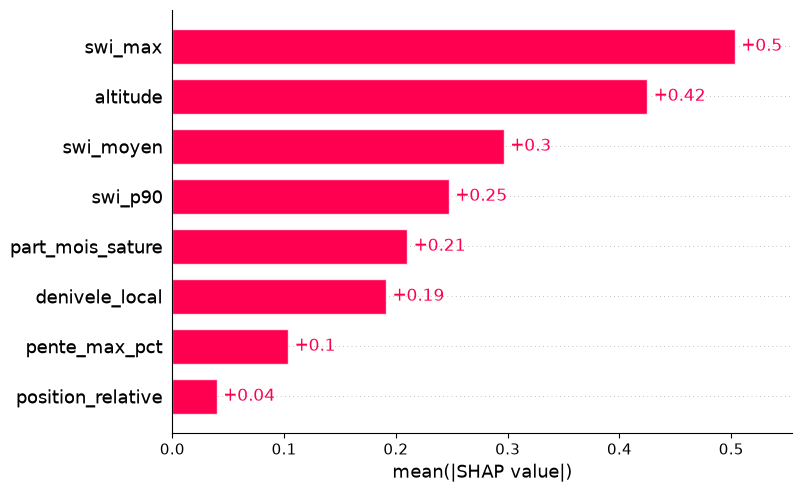

In [2]:
import pandas as pd
import shap
from xgboost import XGBClassifier

# 1. Charger les données
df = pd.read_parquet("../data/communes_cible_swi_relief.parquet")
features = ["swi_moyen", "swi_max", "swi_p90", "part_mois_sature",
            "altitude", "denivele_local", "pente_max_pct", "position_relative"]
X = df[features]
y = df["risque_fort"]

# 2. Recréer et entraîner le modèle sur toutes les communes
poids = (y == 0).sum() / (y == 1).sum()
model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      scale_pos_weight=poids, eval_metric="logloss",
                      random_state=42)
model.fit(X, y)

# 3. Valeurs SHAP et importance globale
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
shap.plots.bar(shap_values)

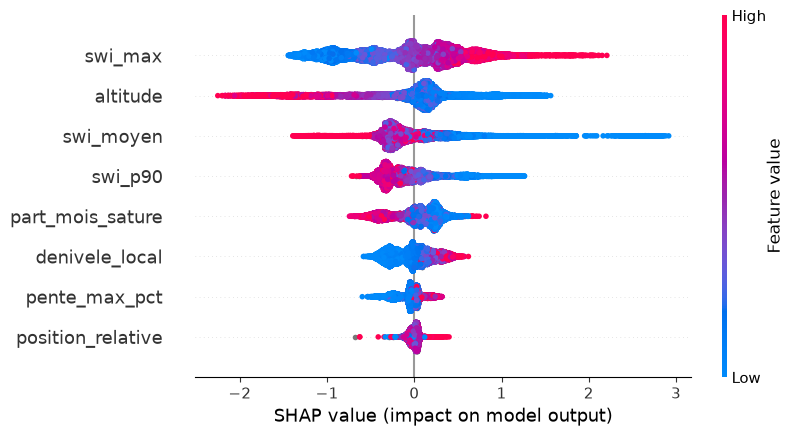

In [3]:
shap.plots.beeswarm(shap_values)

## Interprétation SHAP (modèle v1)
- Altitude : les communes basses sont plus exposées (effet attendu).
- SWI : un SWI max élevé et un SWI moyen faible augmentent le risque. Ce profil (sol souvent sec, saturé ponctuellement) évoque des épisodes de pluies intenses, à vérifier avec des données de pluie (v2).
- Dénivelé local : un relief marqué augmente le risque (cible incluant les coulées de boue).
- Limites : variables SWI corrélées (à interpréter ensemble) ; SHAP explique le modèle, pas une causalité physique.

In [4]:
from sklearn.model_selection import cross_val_predict, GroupKFold

groups = df["codeDepartement"].fillna(df["code_commune"].str[:2])

# Probabilité de risque fort, prédite sans avoir vu le département
df["proba_risque"] = cross_val_predict(
    model, X, y, groups=groups,
    cv=GroupKFold(n_splits=5), method="predict_proba"
)[:, 1]

print(df["proba_risque"].describe().round(3))

# Sauvegarder pour la carte et pour Streamlit
cols = ["code_commune", "nom", "codeDepartement", "lon", "lat",
        "risque_fort", "nb_arretes_inond", "proba_risque"] + features
df[cols].to_parquet("../data/predictions_communes.parquet", index=False)

count    34455.000
mean         0.433
std          0.207
min          0.021
25%          0.276
50%          0.405
75%          0.562
max          0.992
Name: proba_risque, dtype: float64


In [2]:
import pandas as pd
import plotly.express as px

# Recharger les prédictions sauvegardées (pas besoin de relancer le modèle)
df = pd.read_parquet("../data/predictions_communes.parquet")

fig = px.scatter_map(
    df, lat="lat", lon="lon",
    color="proba_risque",
    color_continuous_scale="YlOrRd",   # du jaune (faible) au rouge (fort)
    range_color=(0, 1),
    hover_name="nom",
    hover_data={"nb_arretes_inond": True, "proba_risque": ":.2f",
                "lat": False, "lon": False},
    zoom=4.5, center={"lat": 46.6, "lon": 2.5},
    height=700,
    title="HydraXAI France : probabilité d'exposition forte aux inondations (modèle v1)",
)
fig.update_traces(marker={"size": 3})
fig.show()

In [3]:
# Classer chaque commune selon le type de résultat
seuil = 0.5
df["prediction"] = (df["proba_risque"] >= seuil).astype(int)
df["resultat"] = "Correct"
df.loc[(df["prediction"] == 1) & (df["risque_fort"] == 0), "resultat"] = "Fausse alerte"
df.loc[(df["prediction"] == 0) & (df["risque_fort"] == 1), "resultat"] = "Risque manqué"

print(df["resultat"].value_counts(normalize=True).round(3))

fig_err = px.scatter_map(
    df, lat="lat", lon="lon", color="resultat",
    color_discrete_map={"Correct": "lightgray", "Fausse alerte": "orange",
                        "Risque manqué": "blue"},
    hover_name="nom", zoom=4.5, center={"lat": 46.6, "lon": 2.5}, height=700,
    title="Erreurs du modèle v1",
)
fig_err.update_traces(marker={"size": 3})
fig_err.show()

resultat
Correct          0.697
Fausse alerte    0.202
Risque manqué    0.101
Name: proportion, dtype: float64


In [4]:
fig.write_html("../app/carte_risque_v1.html")